In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
from dataset import CerebellumSliceDataset
from model import SimpleSegmentationCNN
from utils import get_device, set_seed, calculate_dice_score
from loss import CombinedLoss, DiceLoss

In [3]:
set_seed(42)
device = get_device()

In [4]:
train_dataset = CerebellumSliceDataset(dataset_split="train")
val_dataset = CerebellumSliceDataset(dataset_split="val")

train_loader = DataLoader(dataset=train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(dataset=val_dataset, batch_size=4, shuffle=False, num_workers=0)

print(f"Training samples loaded: {len(train_loader)}")
print(f"Validation samples loaded: {len(val_loader)}")

Training samples loaded: 896
Validation samples loaded: 192


In [5]:
cnn = SimpleSegmentationCNN().to(device)
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

In [ ]:
num_epochs = 50
train_losses = []
val_losses = []
val_dice_scores = []

best_val_dice = -torch.inf
best_model_path = "best_cerebellum_model.pth"

criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)

for epoch in range(num_epochs):
    cnn.train()
    running_train_loss = 0.0
    
    for images, masks, patients, filenames in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad() # Clear old gradients because by default they accumulate
        predictions = cnn(images) # Do the forward computation
        loss = criterion(predictions, masks)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    cnn.eval()
    running_val_loss = 0.0
    total_val_dice = 0.0
    
    with torch.no_grad():
        for images, masks, patients, filenames in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            predictions = cnn(images)
            val_loss = criterion(predictions, masks)
            running_val_loss += val_loss.item()
            batch_dice = calculate_dice_score(predictions, masks)
            total_val_dice += batch_dice
    
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    avg_val_dice = total_val_dice / len(val_loader)
    val_dice_scores.append(avg_val_dice)
    
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save({
          "epoch": epoch + 1, 
          "state_dict": cnn.state_dict(), 
          "optimizer": optimizer.state_dict(),
          "val_dice": best_val_dice
        }, best_model_path)
        print(f"--> Saved New Best Model at Epoch {(epoch + 1)} with Val Dice: {best_val_dice:.4f}")
    print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f} | Validation Dice Score: {avg_val_dice:.4f}")

print(f"Best Validation Dice Score achieved: {best_val_dice:.4f}")

--> Saved New Best Model at Epoch 1 with Val Dice: 0.4831
Epoch 1/50 | Train Loss: 0.4834 | Validation Loss: 0.4549 | Validation Dice Score: 0.4831
--> Saved New Best Model at Epoch 2 with Val Dice: 0.4897
Epoch 2/50 | Train Loss: 0.4464 | Validation Loss: 0.4487 | Validation Dice Score: 0.4897
--> Saved New Best Model at Epoch 3 with Val Dice: 0.4931
Epoch 3/50 | Train Loss: 0.4424 | Validation Loss: 0.4422 | Validation Dice Score: 0.4931
--> Saved New Best Model at Epoch 4 with Val Dice: 0.4939
Epoch 4/50 | Train Loss: 0.4406 | Validation Loss: 0.4460 | Validation Dice Score: 0.4939
--> Saved New Best Model at Epoch 5 with Val Dice: 0.4972
Epoch 5/50 | Train Loss: 0.4380 | Validation Loss: 0.4387 | Validation Dice Score: 0.4972
Epoch 6/50 | Train Loss: 0.4371 | Validation Loss: 0.4376 | Validation Dice Score: 0.4967
Epoch 7/50 | Train Loss: 0.4358 | Validation Loss: 0.4368 | Validation Dice Score: 0.4968
--> Saved New Best Model at Epoch 8 with Val Dice: 0.5007
Epoch 8/50 | Train Los

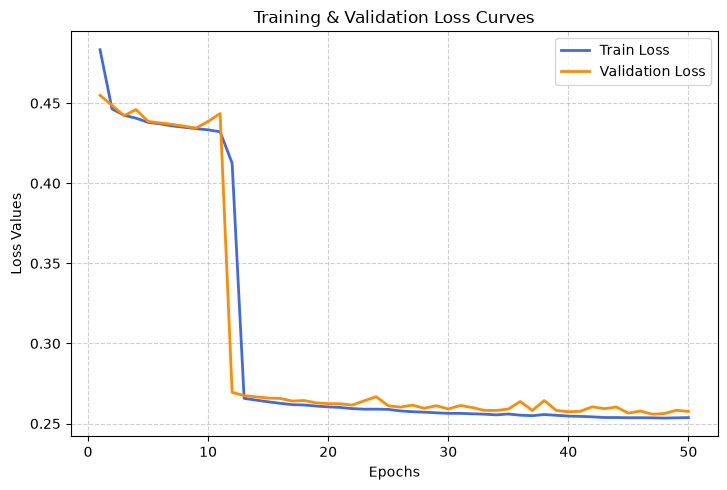

In [7]:
epochs = list(range(1, num_epochs + 1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(epochs, train_losses, label="Train Loss", color="royalblue", linewidth=2)
ax[0].plot(epochs, val_losses, label="Validation Loss", color="darkorange", linewidth=2)

ax[0].set_title("Training & Validation Loss Curves")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss Values")
ax[0].legend()
ax[0].grid(True, linestyle="--", alpha=0.6)

ax[1].set_visible(False)

plt.tight_layout()
plt.show()

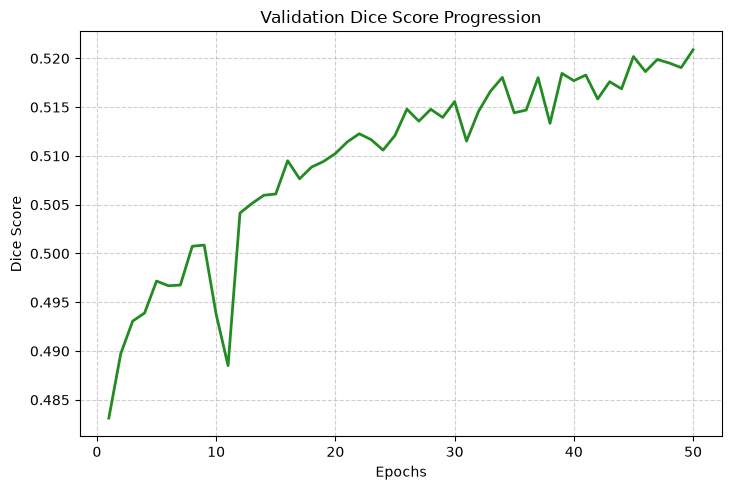

In [8]:
_, new_ax = plt.subplots(1, 2, figsize=(14, 5))

new_ax[0].plot(epochs, val_dice_scores, label="Validation Dice Score", color="forestgreen", linewidth=2)

new_ax[0].set_title("Validation Dice Score Progression")
new_ax[0].set_xlabel("Epochs")
new_ax[0].set_ylabel("Dice Score")
new_ax[0].grid(True, linestyle="--", alpha=0.6)
new_ax[1].set_visible(False)
plt.tight_layout()
plt.show()